In [105]:
import numpy as np
import matplotlib.pyplot as plt
# globally increase the font size for all plots
plt.rcParams.update({'font.size': 16})

In [106]:
def rho_nfw(r, rho_s, r_s):
    """
    NFW profile:
    rho(r) = rho_s / [ (r/r_s) * (1 + r/r_s)^2 ]
    """
    r = np.asarray(r)
    x = r / r_s
    return rho_s / (x * (1 + x)**2)

def rho_gnfw(r, rho_s, r_s, alpha):
    """
    Generalized NFW profile:
    rho(r) = rho_s / [ (r/r_s)^alpha * (1 + r/r_s)^(3 - alpha) ]
    """
    r = np.asarray(r)
    x = r / r_s
    return rho_s / (x**alpha * (1 + x)**(3 - alpha))

def rho_burkert(r, rho_s, r_s):
    """
    Burkert profile:
    rho(r) = rho_s / [ (1 + r/r_s) * (1 + (r/r_s)^2) ]
    """
    r = np.asarray(r)
    x = r / r_s
    return rho_s / ((1 + x) * (1 + x**2))


def rho_einasto(r, rho_s, r_s, alpha):
    """
    Einasto profile:
    rho(r) = rho_s * exp( -2/alpha * [ (r/r_s)^alpha - 1 ] )
    
    Here rho_s is defined at r = r_s.
    """
    r = np.asarray(r)
    x = r / r_s
    return rho_s * np.exp(-2.0/alpha * (x**alpha - 1.0))


def rho_cored_einasto(r, rho_s, r_s, alpha, r_c):
    """
    Cored Einasto profile:
    
    rho(r) = rho_einasto(r_c)  for r < r_c
           = rho_einasto(r)    for r >= r_c
    """
    r = np.asarray(r)
    rho_e = rho_einasto(r, rho_s, r_s, alpha)
    
    # Compute constant core density
    rho_core = rho_einasto(r_c, rho_s, r_s, alpha)
    
    return np.where(r < r_c, rho_core, rho_e)


In [107]:
import numpy as np

# --------------------------------------------
# Geometry
# --------------------------------------------

def los_distance(s, psi, r_sun):
    """
    Galactocentric distance along line of sight.
    
    Parameters
    ----------
    s : array
        Line-of-sight distance(s)
    psi : float
        Opening angle (radians)
    r_sun : float
        Sun-GC distance
    """
    return np.sqrt(r_sun**2 + s**2 - 2.0 * r_sun * s * np.cos(psi))


# --------------------------------------------
# Grid generator
# --------------------------------------------

def generate_los_grid(s_max, n_steps=1000, log_integration=False, s_min=1e-6):
    """
    Generate line-of-sight integration grid.
    
    Parameters
    ----------
    s_max : float
    n_steps : int
    log_integration : bool
        If True, use logarithmic spacing
    s_min : float
        Minimum s for log grid
    """
    if log_integration:
        return np.logspace(np.log10(s_min), np.log10(s_max), n_steps)
    else:
        return np.linspace(0.0, s_max, n_steps)


# --------------------------------------------
# Differential J-factor
# --------------------------------------------
KPC_TO_CM = 3.085677581e21
def differential_J_trapz(
    psi,
    rho_func,
    r_sun,
    s_max,
    n_steps=2000,
    log_integration=False,
    s_min=1e-6,
    convert_to_cm=True,
    **rho_kwargs
):
    """
    Compute dJ/dOmega using trapezoidal integration.
    
    Returns:
        GeV^2 cm^-5 sr^-1  (if convert_to_cm=True)
        GeV^2 cm^-6 kpc    (otherwise)
    """

    s = generate_los_grid(
        s_max,
        n_steps=n_steps,
        log_integration=log_integration,
        s_min=s_min
    )

    r = los_distance(s, psi, r_sun)
    rho_vals = rho_func(r, **rho_kwargs)

    integrand = rho_vals**2
    J = np.trapezoid(integrand, s)

    if convert_to_cm:
        J *= KPC_TO_CM

    return J


# --------------------------------------------
# Differential D-factor
# --------------------------------------------

def differential_D_trapz(
    psi,
    rho_func,
    r_sun,
    s_max,
    n_steps=2000,
    log_integration=False,
    s_min=1e-6,
    convert_to_cm=True,
    **rho_kwargs
):
    """
    Compute dD/dOmega using trapezoidal integration.
    """
    
    s = generate_los_grid(
        s_max,
        n_steps=n_steps,
        log_integration=log_integration,
        s_min=s_min
    )
    
    r = los_distance(s, psi, r_sun)
    rho_vals = rho_func(r, **rho_kwargs)
    
    D = np.trapezoid(rho_vals, s)

    if convert_to_cm:
        D *= KPC_TO_CM
    return D


# --------------------------------------------
# Vectorized over psi
# --------------------------------------------

def compute_J_profile_trapz(
    psi_array,
    rho_func,
    r_sun,
    s_max,
    n_steps=2000,
    log_integration=False,
    s_min=1e-6,
    **rho_kwargs
):
    return np.array([
        differential_J_trapz(
            psi,
            rho_func,
            r_sun,
            s_max,
            n_steps=n_steps,
            log_integration=log_integration,
            s_min=s_min,
            **rho_kwargs
        )
        for psi in psi_array
    ])


def compute_D_profile_trapz(
    psi_array,
    rho_func,
    r_sun,
    s_max,
    n_steps=2000,
    log_integration=False,
    s_min=1e-6,
    **rho_kwargs
):
    return np.array([
        differential_D_trapz(
            psi,
            rho_func,
            r_sun,
            s_max,
            n_steps=n_steps,
            log_integration=log_integration,
            s_min=s_min,
            **rho_kwargs
        )
        for psi in psi_array
    ])



# DM density profile

In [108]:
# Milky Way Burkert:
rho_s_burkert = 1.57  # GeV/cm^3
r_s_burkert = 9.26  # kpc
# Milky Way NFW:
rho_s_nfw = 0.532  # GeV/cm^3
r_s_nfw = 16.1  # kpc
# Milky Way Einasto:
rho_s_einasto = 0.081  # GeV/cm^3
r_s_einasto = 20.0  # kpc
alpha_einasto = 0.17
# Milky Way Cored Einasto:
rho_s_cored_einasto = 0.081  # GeV/cm^3
r_s_cored_einasto = 20.0  # kpc
alpha_cored_einasto = 0.17

In [109]:
# corresponding local density:
rho_local_burkert = rho_burkert(8.5, rho_s_burkert, r_s_burkert)
rho_local_nfw = rho_nfw(8.5, rho_s_nfw, r_s_nfw)
rho_local_einasto = rho_einasto(8.5, rho_s_einasto, r_s_einasto, alpha_einasto)
print(f"Local density (Burkert): {rho_local_burkert:.3f} GeV/cm^3 at r = 8.5 kpc")
print(f"Local density (NFW): {rho_local_nfw:.3f} GeV/cm^3 at r = 8.5 kpc")
print(f"Local density (Einasto): {rho_local_einasto:.3f} GeV/cm^3 at r = 8.5 kpc")

Local density (Burkert): 0.444 GeV/cm^3 at r = 8.5 kpc
Local density (NFW): 0.432 GeV/cm^3 at r = 8.5 kpc
Local density (Einasto): 0.398 GeV/cm^3 at r = 8.5 kpc


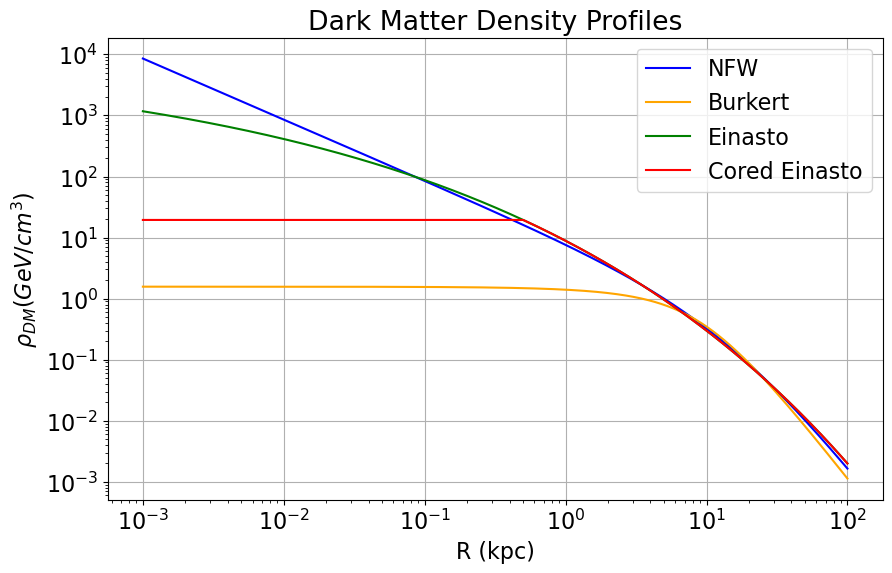

In [110]:
# plot DM profiles
r = np.logspace(-3, 2, 1000)  # kpc
plt.figure(figsize=(10, 6))
plt.loglog(r, rho_nfw(r, rho_s_nfw, r_s_nfw), label='NFW', color='blue')
plt.loglog(r, rho_burkert(r, rho_s_burkert, r_s_burkert), label='Burkert', color='orange')
plt.loglog(r, rho_einasto(r, rho_s_einasto, r_s_einasto, alpha_einasto), label='Einasto', color='green')
plt.loglog(r, rho_cored_einasto(r, rho_s_cored_einasto, r_s_cored_einasto, alpha_cored_einasto, r_c=0.5), label='Cored Einasto', color='red')
plt.xlabel('R (kpc)')
plt.ylabel(r'$\rho_{DM}(GeV/cm^3)$')
plt.title('Dark Matter Density Profiles')
plt.legend()
plt.grid()

# Comparison across different parameter choices

In [111]:
# Nesti Salucci parameters for Milky Way: https://arxiv.org/pdf/1304.5127
PARAMS_NESTI = {"NFW": {"rho_s": 0.532, "r_s": 16.1}, "Burkert": {"rho_s": 1.57, "r_s": 9.26}}
R_SUN_NESTI = {"NFW": 8.08, "Burkert": 7.94}
# Benito parameters for Milky Way:
# Km3NeT VHE DM paper quote this: https://www.sciencedirect.com/science/article/pii/S2212686421000571?via%3Dihub
# # But this ref only quote the 2sigma range not the bestfit!
PARAMS_BENITO = {"NFW": {"rho_s": 0.23, "r_s": 25.}, "Burkert": {"rho_s": 0.59, "r_s": 25.}, "Einasto":{"rho_s": 0.08, "r_s": 20., "alpha": 0.17}}
R_SUN_BENITO = {"NFW": 8.178, "Burkert": 8.178, "Einasto": 8.178}
# Ou 2023 https://arxiv.org/pdf/2303.12838
PARAMS_OU = {"Einasto": {"rho_s": 1.65, "r_s": 3.86, "alpha": 0.91}, "gNFW": {"rho_s": 6.67, "r_s": 5.26, "alpha": 0.0258}}
R_SUN_OU = {"Einasto": 8.122, "gNFW": 8.122}

In [112]:
# Local density for each choice:
rho_local_nesti_nfw = rho_nfw(R_SUN_NESTI["NFW"], **PARAMS_NESTI["NFW"])
rho_local_nesti_burkert = rho_burkert(R_SUN_NESTI["Burkert"], **PARAMS_NESTI["Burkert"])
rho_local_benito_nfw = rho_nfw(R_SUN_BENITO["NFW"], **PARAMS_BENITO["NFW"])
rho_local_benito_burkert = rho_burkert(R_SUN_BENITO["Burkert"], **PARAMS_BENITO["Burkert"])
rho_local_benito_einasto = rho_einasto(R_SUN_BENITO["Einasto"], **PARAMS_BENITO["Einasto"])
rho_local_ou_einasto = rho_einasto(R_SUN_OU["Einasto"], **PARAMS_OU["Einasto"])
rho_local_ou_gnfw = rho_gnfw(R_SUN_OU["gNFW"], **PARAMS_OU["gNFW"])
print(f"Nesti NFW local density: {rho_local_nesti_nfw:.3f} GeV/cm^3 at r = {R_SUN_NESTI['NFW']} kpc")
print(f"Nesti Burkert local density: {rho_local_nesti_burkert:.3f} GeV/cm^3 at r = {R_SUN_NESTI['Burkert']} kpc")
print(f"Benito NFW local density: {rho_local_benito_nfw:.3f} GeV/cm^3 at r = {R_SUN_BENITO['NFW']} kpc")
print(f"Benito Burkert local density: {rho_local_benito_burkert:.3f} GeV/cm^3 at r = {R_SUN_BENITO['Burkert']} kpc")
print(f"Benito Einasto local density: {rho_local_benito_einasto:.3f} GeV/cm^3 at r = {R_SUN_BENITO['Einasto']} kpc")
print(f"Ou Einasto local density: {rho_local_ou_einasto:.3f} GeV/cm^3 at r = {R_SUN_OU['Einasto']} kpc")
print(f"Ou gNFW local density: {rho_local_ou_gnfw:.3f} GeV/cm^3 at r = {R_SUN_OU['gNFW']} kpc")

Nesti NFW local density: 0.470 GeV/cm^3 at r = 8.08 kpc
Nesti Burkert local density: 0.487 GeV/cm^3 at r = 7.94 kpc
Benito NFW local density: 0.399 GeV/cm^3 at r = 8.178 kpc
Benito Burkert local density: 0.402 GeV/cm^3 at r = 8.178 kpc
Benito Einasto local density: 0.420 GeV/cm^3 at r = 8.178 kpc
Ou Einasto local density: 0.197 GeV/cm^3 at r = 8.122 kpc
Ou gNFW local density: 0.410 GeV/cm^3 at r = 8.122 kpc


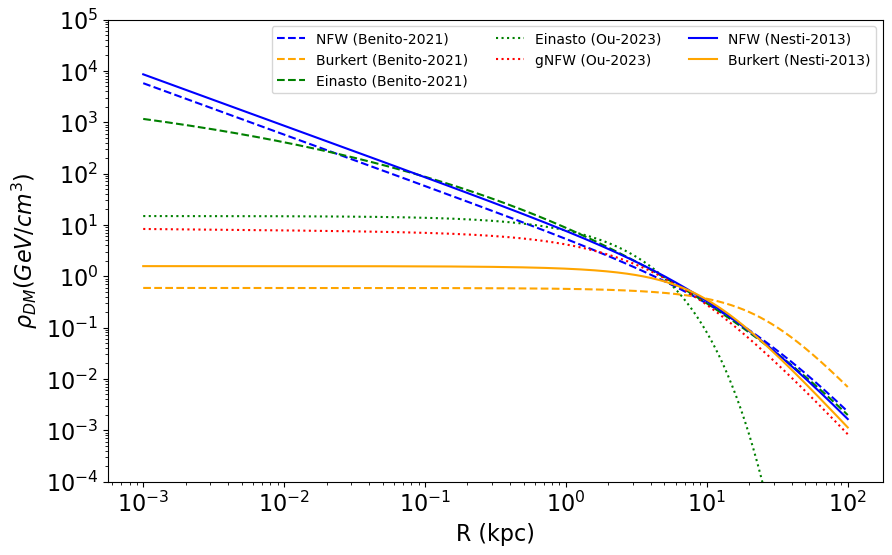

In [113]:
# Plot different DM density profiles
r = np.logspace(-3, 2, 1000)  # kpc
plt.figure(figsize=(10, 6))
plt.loglog(r, rho_nfw(r, PARAMS_BENITO["NFW"]["rho_s"], PARAMS_BENITO["NFW"]["r_s"]), label='NFW (Benito-2021)', color='blue', ls='--')
plt.loglog(r, rho_burkert(r, PARAMS_BENITO["Burkert"]["rho_s"], PARAMS_BENITO["Burkert"]["r_s"]), label='Burkert (Benito-2021)', color='orange', ls='--')
plt.loglog(r, rho_einasto(r, PARAMS_BENITO["Einasto"]["rho_s"], PARAMS_BENITO["Einasto"]["r_s"], PARAMS_BENITO["Einasto"]["alpha"]), label='Einasto (Benito-2021)', color='green', ls='--')
plt.loglog(r, rho_einasto(r, PARAMS_OU["Einasto"]["rho_s"], PARAMS_OU["Einasto"]["r_s"], PARAMS_OU["Einasto"]["alpha"]), label='Einasto (Ou-2023)', color='green', ls=":")
plt.loglog(r, rho_gnfw(r, PARAMS_OU["gNFW"]["rho_s"], PARAMS_OU["gNFW"]["r_s"], PARAMS_OU["gNFW"]["alpha"]), label='gNFW (Ou-2023)', color='red', ls=":")
plt.loglog(r, rho_nfw(r, PARAMS_NESTI["NFW"]["rho_s"], PARAMS_NESTI["NFW"]["r_s"]), label='NFW (Nesti-2013)', color='blue')
plt.loglog(r, rho_burkert(r, PARAMS_NESTI["Burkert"]["rho_s"], PARAMS_NESTI["Burkert"]["r_s"]), label='Burkert (Nesti-2013)', color='orange')
plt.xlabel('R (kpc)')
plt.ylabel(r'$\rho_{DM}(GeV/cm^3)$')
plt.ylim(1e-4, 1e5)
plt.legend(ncol=3, fontsize=10)

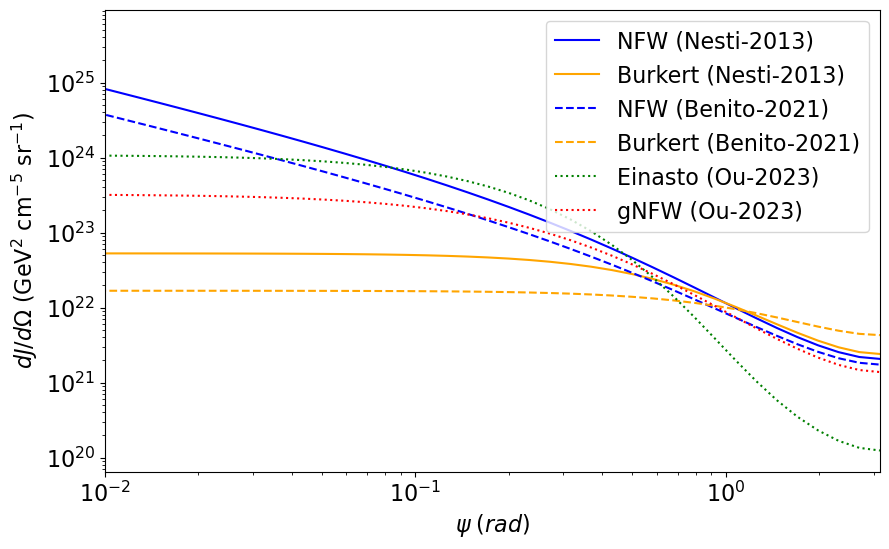

In [114]:
# Jfactors for Nesti Salucci and Benito parameters
psi_array = np.deg2rad(np.geomspace(1e-1, 180))  # degrees
J_nesti_nfw = compute_J_profile_trapz(psi_array, rho_nfw, R_SUN_NESTI["NFW"], s_max, n_steps=20000, log_integration=False, s_min=1e-6, **PARAMS_NESTI["NFW"])
J_nesti_burkert = compute_J_profile_trapz(psi_array, rho_burkert, R_SUN_NESTI["Burkert"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_NESTI["Burkert"])
J_benito_nfw = compute_J_profile_trapz(psi_array, rho_nfw, R_SUN_BENITO["NFW"], s_max, n_steps=20000, log_integration=False, s_min=1e-6, **PARAMS_BENITO["NFW"])
J_benito_burkert = compute_J_profile_trapz(psi_array, rho_burkert, R_SUN_BENITO["Burkert"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_BENITO["Burkert"])
J_ou_einasto = compute_J_profile_trapz(psi_array, rho_einasto, R_SUN_OU["Einasto"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_OU["Einasto"])
J_ou_gnfw = compute_J_profile_trapz(psi_array, rho_gnfw, R_SUN_OU["gNFW"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_OU["gNFW"])
# plot J-factors
plt.figure(figsize=(10, 6))
plt.plot(psi_array, J_nesti_nfw, label='NFW (Nesti-2013)', color='blue')
plt.plot(psi_array, J_nesti_burkert, label='Burkert (Nesti-2013)', color='orange')
plt.plot(psi_array, J_benito_nfw, label='NFW (Benito-2021)', color='blue', ls='--')
plt.plot(psi_array, J_benito_burkert, label='Burkert (Benito-2021)', color='orange', ls='--')
plt.plot(psi_array, J_ou_einasto, label='Einasto (Ou-2023)', color='green', ls=":")
plt.plot(psi_array, J_ou_gnfw, label='gNFW (Ou-2023)', color='red', ls=":")
plt.semilogy()
plt.semilogx()
plt.xlabel(r'$\psi \;(rad)$')
plt.xlim(1e-2, 3.14)
plt.ylabel(r'$dJ/d\Omega$ (GeV$^2$ cm$^{-5}$ sr$^{-1}$)')
plt.legend()

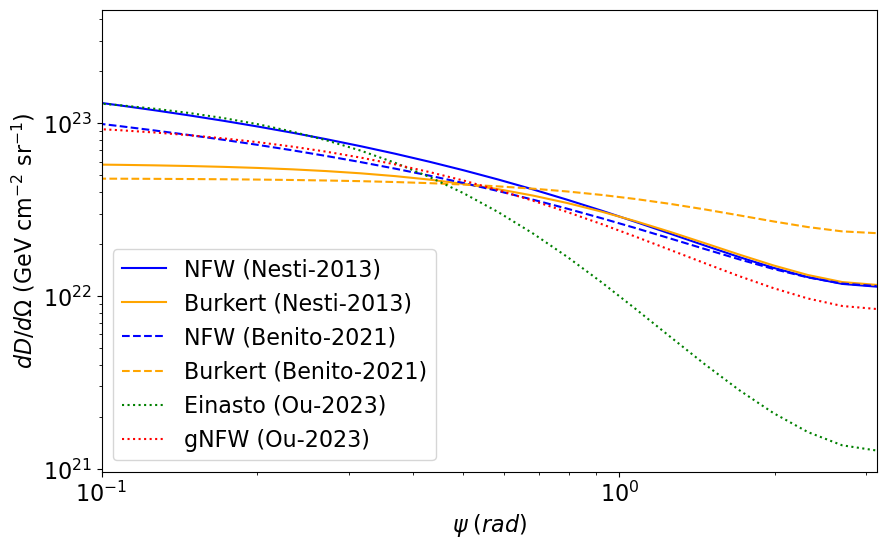

In [115]:
# D-factors for Nesti Salucci and Benito parameters
D_nesti_nfw = compute_D_profile_trapz(psi_array, rho_nfw, R_SUN_NESTI["NFW"], s_max, n_steps=20000, log_integration=False, s_min=1e-6, **PARAMS_NESTI["NFW"])
D_nesti_burkert = compute_D_profile_trapz(psi_array, rho_burkert, R_SUN_NESTI["Burkert"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_NESTI["Burkert"])
D_benito_nfw = compute_D_profile_trapz(psi_array, rho_nfw, R_SUN_BENITO["NFW"], s_max, n_steps=20000, log_integration=False, s_min=1e-6, **PARAMS_BENITO["NFW"])
D_benito_burkert = compute_D_profile_trapz(psi_array, rho_burkert, R_SUN_BENITO["Burkert"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_BENITO["Burkert"])
D_ou_einasto = compute_D_profile_trapz(psi_array, rho_einasto, R_SUN_OU["Einasto"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_OU["Einasto"])
D_ou_gnfw = compute_D_profile_trapz(psi_array, rho_gnfw, R_SUN_OU["gNFW"], s_max, n_steps=20000, log_integration=True, s_min=1e-6, **PARAMS_OU["gNFW"])
# plot D-factors
plt.figure(figsize=(10, 6))
plt.plot(psi_array, D_nesti_nfw, label='NFW (Nesti-2013)', color='blue')
plt.plot(psi_array, D_nesti_burkert, label='Burkert (Nesti-2013)', color='orange')
plt.plot(psi_array, D_benito_nfw, label='NFW (Benito-2021)', color='blue', ls='--')
plt.plot(psi_array, D_benito_burkert, label='Burkert (Benito-2021)', color='orange', ls='--')
plt.plot(psi_array, D_ou_einasto, label='Einasto (Ou-2023)', color='green', ls=":")
plt.plot(psi_array, D_ou_gnfw, label='gNFW (Ou-2023)', color='red', ls=":")
plt.semilogy()
plt.semilogx()
plt.xlabel(r'$\psi \;(rad)$')
plt.xlim(1e-1, 3.14)
plt.ylabel(r'$dD/d\Omega$ (GeV cm$^{-2}$ sr$^{-1}$)')
plt.legend()
plt.show()